In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import accuracy_score, mean_squared_error
import seaborn as sns
import warnings
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [60]:
#helper functions 
def find_null_values_in_cols(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0]

def get_na_columns(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0].keys()

# data cleaning functions
def find_bad_storms(df, na_columns):
    # find storms where ALL values are null for any of the cols
    bad_storms = []
    for storm in df['typhoon_name'].unique():
        for col in na_columns:
            if df[df['typhoon_name'] == storm][col].isna().all():
                bad_storms.append(storm)
                break  # no need to check other cols

    bad_storms = list(set(bad_storms))
    return bad_storms

def calculate_storm_medians(df, cols):
    '''
    This function will calculate storm-specific medians for the affected cells and creates a dictionary
    so we can do this for the test set as well.
    '''
    storm_medians = {}
    for storm in df['typhoon_name'].unique():
        storm_medians[storm] = {}
        for col in cols:
            prob_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 1)][col].median()
            not_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 0)][col].median()
            overall_median = df[df['typhoon_name'] == storm][col].median()

            storm_medians[storm][col] = {
                'prob_aff': prob_median,
                'not_affected': not_median,
                'overall_median': overall_median
            }
    return storm_medians

def get_storm_median_for_row(row, storm_medians, col):
    '''
    This function will get the storm-specific medians for a given row, and will check if the s
    '''
    storm_name = row['typhoon_name']
    
    # fallback if storm not seen during training
    if storm_name not in storm_medians:
        return np.nan  # or a global median you pass in
    
    medians = storm_medians[storm_name][col]
    
    if row['prob_aff'] == 1 and not pd.isna(medians['prob_aff']):
        return medians['prob_aff']
    elif row['prob_aff'] == 0 and not pd.isna(medians['not_affected']):
        return medians['not_affected']
    else:
        return medians['overall_median']
    
def simp_calculate_storm_medians(df, cols):
    '''
    Calculates the overall storm median for each column and returns a dictionary.
    '''
    storm_medians = {}
    for storm in df['typhoon_name'].unique():
        storm_medians[storm] = {}
        for col in cols:
            storm_medians[storm][col] = df[df['typhoon_name'] == storm][col].median()
    return storm_medians

def impute_with_storm_medians(df, storm_medians, cols, global_medians=None):
    '''
    Replaces null values in cols with the storm-specific median.
    Falls back to global median if storm not seen during training.
    '''
    df = df.copy()
    for col in cols:
        for storm in df['typhoon_name'].unique():
            mask = (df['typhoon_name'] == storm) & (df[col].isna())
            if storm in storm_medians:
                df.loc[mask, col] = storm_medians[storm][col]
            else:
                # fallback for unseen storms
                fallback = global_medians[col] if global_medians else df[col].median()
                df.loc[mask, col] = fallback
    return df

def drop_correlated_features(X_train,y_train,method='spearman'):
    
    corr_cols_to_drop = []
    cols_to_skip = []

    for i, col in enumerate(X_train.columns):
        for j in X_train.columns[i+1:]:
            if j in cols_to_skip:
                continue  # skip this column as it's already marked for dropping
            corr = X_train[[col, j]].corr(method=method).iloc[0, 1]
            col_corr = X_train[col].corr(y_train.squeeze(),method=method)
            j_corr = X_train[j].corr(y_train.squeeze(),method=method)
            if abs(corr) > 0.75:
                if abs(col_corr) < abs(j_corr):
                    corr_cols_to_drop.append(col)
                    break  # drop col and move to next one
                else:
                    corr_cols_to_drop.append(j)
                    cols_to_skip.append(j)  # skip j in future comparisons
                    continue  # keep col and compare it with next features

    return corr_cols_to_drop

In [31]:
#read in the data
df = pd.read_csv('../data/target/model_training_data_new.csv')

#drop the missing storms
na_cols = get_na_columns(df)
bad_storms = find_bad_storms(df, na_cols)
df_clean = df[~df['typhoon_name'].isin(bad_storms)]

#get the correct y and X for the clean data
y_1 = df_clean[['percent_houses_damaged']]
y_2 = df_clean[['percent_houses_damaged_5years']]
X = df_clean.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_1, random_state=42)

Do the same data cleaning from before:

In [32]:
na_columns = get_na_columns(X)
median_dict = calculate_storm_medians(X_train, na_columns)

# now applying these to both the train and test set, so we can impute the nulls with the storm-specific medians
for col in na_columns:
    # only impute where null — preserve existing values
    null_mask_train = X_train[col].isna()
    null_mask_test = X_test[col].isna()

    X_train.loc[null_mask_train, col] = X_train[null_mask_train].apply(
        lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
    )
    X_test.loc[null_mask_test, col] = X_test[null_mask_test].apply(
        lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
    )



In [33]:
#drop the typhoon name for modeling
X_train = X_train.drop(columns=['typhoon_name','typhoon_year'])
X_test = X_test.drop(columns=['typhoon_name','typhoon_year'])

Things to look into:

1. Log-transform y if skewed         → biggest impact if target is skewed
2. Scale features                    → quick win, easy to test
3. Clip outliers                     → especially if a few extreme values exist
4. Compare feature importances       → check XGBoost isn't ignoring key features

In [36]:
from sklearn.preprocessing import MinMaxScaler

# Create a copy of the training data and apply min-max scaling
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

trying the model from before with the new scaled data.

In [40]:
# Step 1: First tune tree structure
param_grid_1 = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5]       # Minimum loss reduction to split
}

# Step 2: Then tune sampling (after step 1 finds best tree params)
param_grid_2 = {
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Step 3: Then tune regularization
param_grid_3 = {
    'reg_alpha': [0, 0.01, 0.1, 1, 10],    # L1
    'reg_lambda': [0.1, 1, 5, 10, 50]       # L2
}

fill_gs = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],    # L1
    'reg_lambda': [0.1, 1, 5, 10, 50]
}


# Base estimator - start with a lower learning rate and more trees
base_xgb = xgb.XGBRegressor(
    learning_rate=0.05,
    n_estimators=500,
    objective='reg:squarederror',
    n_jobs=4,
    random_state=42,
    colsample_bytree=1.0,
    subsample=1.0,
    gamma=0.1
)

# from first round
# {'gamma': 0.1, 'max_depth': 5, 'min_child_weight': 1}

# {'colsample_bytree': 1.0, 'subsample': 1.0}

# Run step 1 first
gsearch1 = GridSearchCV(
    estimator=base_xgb,
    param_grid=fill_gs,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    cv=5,
    verbose=2
)

gsearch1.fit(X_train, y_train)
y_pred = gsearch1.predict(X_test)
print(f"Best params: {gsearch1.best_params_}")
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Fitting 5 folds for each of 1600 candidates, totalling 8000 fits
[CV] END gamma=0, max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1; total time=   0.9s
[CV] END gamma=0, max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1; total time=   1.0s
[CV] END gamma=0, max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1; total time=   1.0s
[CV] END gamma=0, max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1; total time=   1.0s
[CV] END gamma=0, max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1; total time=   1.0s
[CV] END gamma=0, max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=1; total time=   1.0s
[CV] END gamma=0, max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=1; total time=   1.0s
[CV] END gamma=0, max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=1; total time=   1.0s
[CV] END gamma=0, max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=1; total time=   0.8s
[CV] END gamma=0, max_depth=3, min_child_weight=1, r

In [16]:
# Compare which features each model relies on
# rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
xgb_importances = pd.Series(base_xgb.feature_importances_, index=X_train.columns)

# print("Top 10 RF features:")
# print(rf_importances.nlargest(10))

print("\nTop 10 XGB features:")
print(xgb_importances.nlargest(10))


Top 10 XGB features:
median_pre_event_mean               0.125345
affected_perc                       0.110534
mean_DPmax                          0.103394
mean_pre_event_mean                 0.099907
minority_aff                        0.085408
grid_point_id                       0.085194
mean_preevent_avail                 0.084926
prop_NODATA_VALUE_pre_event_mean    0.056322
mean_available                      0.051730
median_DPmax                        0.043266
dtype: float32


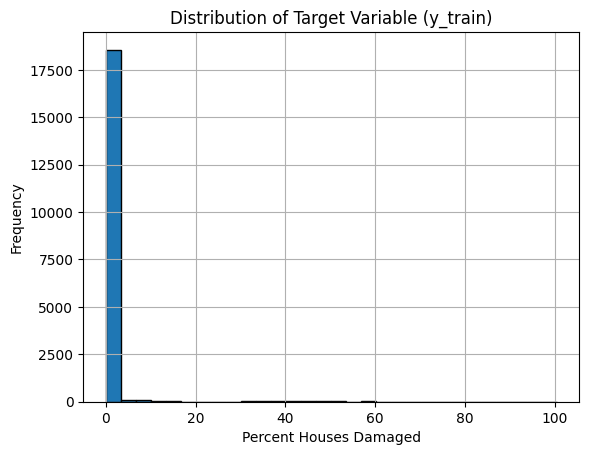

Test R²:   -0.0692
Test RMSE: 5.4447


In [27]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

y_train.hist(bins=30, edgecolor='k')
plt.title('Distribution of Target Variable (y_train)')
plt.xlabel('Percent Houses Damaged')
plt.ylabel('Frequency')
plt.show()

from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# # --- Option 1: Yeo-Johnson ---
# pt = PowerTransformer(method='yeo-johnson')
# y_train_transformed = pt.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# # Fit model on transformed y
# base_xgb.fit(X_train_scaled, y_train_transformed)

# # Predict in transformed scale
# y_pred_transformed = base_xgb.predict(X_test_scaled)

# # Reverse transform back to original scale
# y_pred = pt.inverse_transform(y_pred_transformed.reshape(-1, 1)).ravel()

# # Evaluate against original y_test
# print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")
# print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


# --- Option 2: Quantile Transform ---
qt = QuantileTransformer(output_distribution='normal')
y_train_transformed = qt.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Fit model on transformed y
base_xgb.fit(X_train, y_train_transformed)

# Predict in transformed scale
y_pred_transformed = base_xgb.predict(X_test)

# Reverse transform back to original scale
y_pred = qt.inverse_transform(y_pred_transformed.reshape(-1, 1)).ravel()

# Evaluate against original y_test
print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# # If skewed, log transform
# y_train_log = np.log1p(y_train)  # log1p handles zeros safely
# y_test_log = np.log1p(y_test)


# # Fit on the log-transformed target
# base_xgb.fit(X_train_scaled, y_train_log)

# # Predict (outputs are in log scale)
# y_pred_log = base_xgb.predict(X_test_scaled)

# # Reverse transform to get predictions in original scale
# y_pred = np.expm1(y_pred_log)

# # Evaluate against the original y_test (not log-transformed)
# test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# test_r2 = r2_score(y_test, y_pred)

# print(f"Test RMSE: {test_rmse:.4f}")
# print(f"Test R²:   {test_r2:.4f}")

New model with the more simplified version of imputing nulls

In [53]:
#get the correct y and X for the clean data
y_2 = df_clean[['percent_houses_damaged']]
X_2 = df_clean.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

# Split the data
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, random_state=42)

In [54]:
na_columns = get_na_columns(X)
# get medians
storm_medians = calculate_storm_medians(X_train_2, na_columns)
global_medians = X_train_2[na_columns].median().to_dict()  # fallback for unseen storms

X_train_imputed = impute_with_storm_medians(X_train_2, storm_medians, na_columns, global_medians)
X_test_imputed  = impute_with_storm_medians(X_test_2, storm_medians, na_columns, global_medians)

# drop columns that only have one value and therefore don't provide value
cols_to_drop = []
for col in X_train_imputed.columns:
    if X_train_imputed[col].value_counts().shape[0] == 1:
        cols_to_drop.append(col)
    
X_train_imputed.drop(columns=cols_to_drop, inplace=True)
X_test_imputed.drop(columns=cols_to_drop, inplace=True)

In [55]:
X_train_imputed.drop(columns=['typhoon_name','grid_point_id'], inplace=True)
X_test_imputed.drop(columns=['typhoon_name','grid_point_id'], inplace=True)

Baseline check to see how this new data preforms, I think we'll do it without potentially the grid_id:

In [57]:
# Step 1: First tune tree structure
param_grid_1 = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5]       # Minimum loss reduction to split
}

# Step 2: Then tune sampling (after step 1 finds best tree params)
param_grid_2 = {
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Step 3: Then tune regularization
param_grid_3 = {
    'reg_alpha': [0, 0.01, 0.1, 1, 10],    # L1
    'reg_lambda': [0.1, 1, 5, 10, 50]       # L2
}

fill_gs = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    # 'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.1, 1, 10],    # L1
    'reg_lambda': [0.1, 1, 5, 10]
}


# Base estimator - start with a lower learning rate and more trees
base_xgb = xgb.XGBRegressor(
    learning_rate=0.05,
    n_estimators=500,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42,
    colsample_bytree=1.0,
    subsample=1.0,
    gamma=0.1
)

# from first round
# {'gamma': 0.1, 'max_depth': 5, 'min_child_weight': 1}

# {'colsample_bytree': 1.0, 'subsample': 1.0}

# Run step 1 first
gsearch1 = GridSearchCV(
    estimator=base_xgb,
    param_grid=fill_gs,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    cv=5,
    verbose=1000
)

gsearch1.fit(X_train_imputed, y_train_2)
y_pred_2 = gsearch1.predict(X_test_imputed)
print(f"Best params: {gsearch1.best_params_}")
# Evaluate model performance
mse_2 = mean_squared_error(y_test_2, y_pred_2)
r2_2 = r2_score(y_test_2, y_pred_2)

print(f"Mean Squared Error: {mse_2:.2f}")
print(f"R-squared: {r2_2:.2f}")

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV 3/5; 1/256] START max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1
[CV 4/5; 1/256] START max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1
[CV 5/5; 1/256] START max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1
[CV 2/5; 2/256] START max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=1
[CV 1/5; 1/256] START max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1
[CV 2/5; 1/256] START max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1
[CV 1/5; 2/256] START max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=1
[CV 3/5; 2/256] START max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=1
[CV 3/5; 1/256] END max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1;, score=-4.234 total time=   1.0s
[CV 4/5; 2/256] START max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=1
[CV 5/5; 1/256] END max_depth=3, min_child_weight=1, reg_alpha=0, reg_lambda=0.1;,

get rid of highly correlated columns: 

In [59]:
def drop_correlated_features(X_train,y_train,method='spearman'):
    corr_cols_to_drop = []
    cols_to_skip = []
    for i, col in enumerate(X_train.columns):
        for j in X_train.columns[i+1:]:
            if j in cols_to_skip:
                continue  # skip this column as it's already marked for dropping
            corr = X_train[[col, j]].corr(method=method).iloc[0, 1]
            col_corr = X_train[col].corr(y_train.squeeze(),method=method)
            j_corr = X_train[j].corr(y_train.squeeze(),method=method)
            if abs(corr) > 0.75:
                if abs(col_corr) < abs(j_corr):
                    corr_cols_to_drop.append(col)
                    break  # drop col and move to next one
                else:
                    corr_cols_to_drop.append(j)
                    cols_to_skip.append(j)  # skip j in future comparisons
                    continue  # keep col and compare it with next features

    return corr_cols_to_drop

In [ ]:
corr_cols_to_drop = drop_correlated_features(df, target_col, threshold=0.7)